In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

In [3]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [6]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [7]:
df["addiction_level"]=df["addiction_level"].fillna("Unknown")

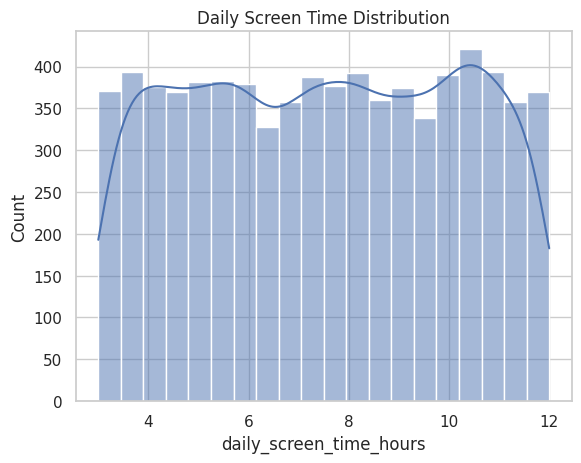

In [8]:
plt.figure()
sns.histplot(df["daily_screen_time_hours"], kde=True)
plt.title("Daily Screen Time Distribution")
plt.show()

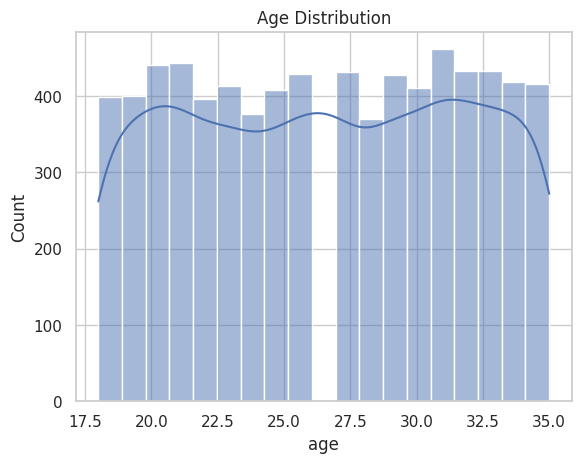

In [9]:
plt.figure()
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

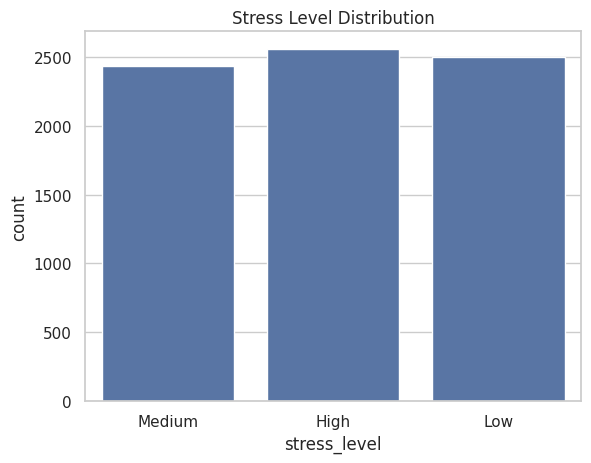

In [10]:
plt.figure()
sns.countplot(x=df["stress_level"])
plt.title("Stress Level Distribution")
plt.show()

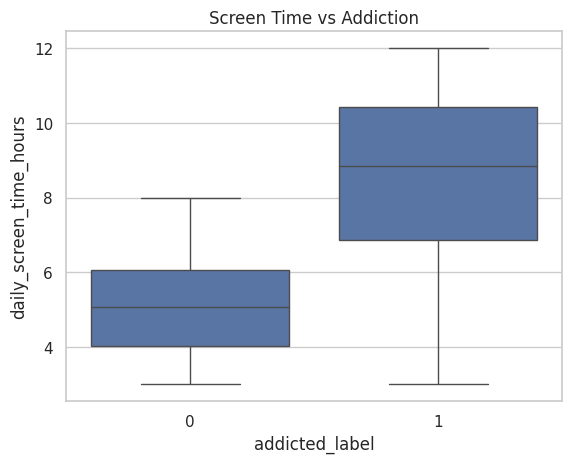

In [11]:
plt.figure()
sns.boxplot(x="addicted_label", y="daily_screen_time_hours", data=df)
plt.title("Screen Time vs Addiction")
plt.show()

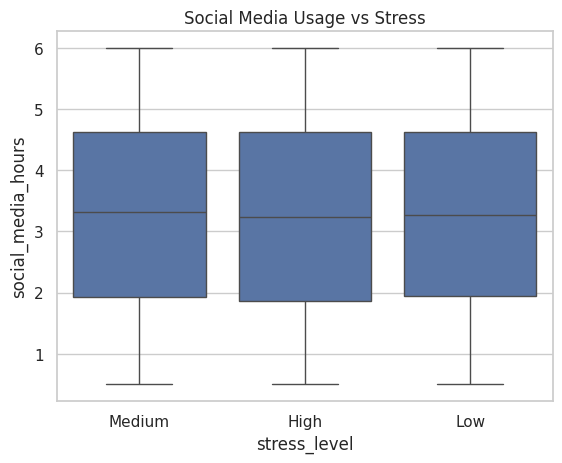

In [12]:
plt.figure()
sns.boxplot(x="stress_level", y="social_media_hours", data=df)
plt.title("Social Media Usage vs Stress")
plt.show()

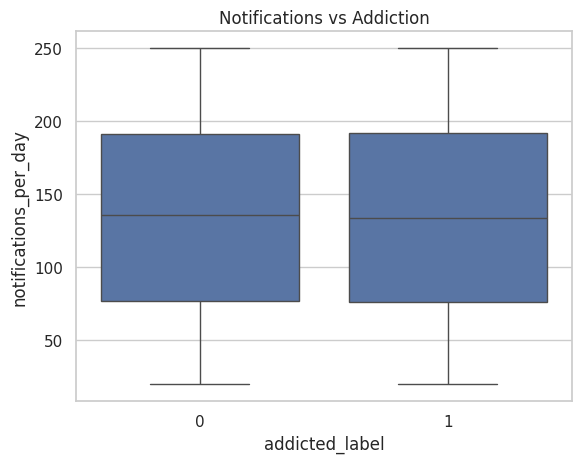

In [13]:
plt.figure()
sns.boxplot(x="addicted_label", y="notifications_per_day", data=df)
plt.title("Notifications vs Addiction")
plt.show()

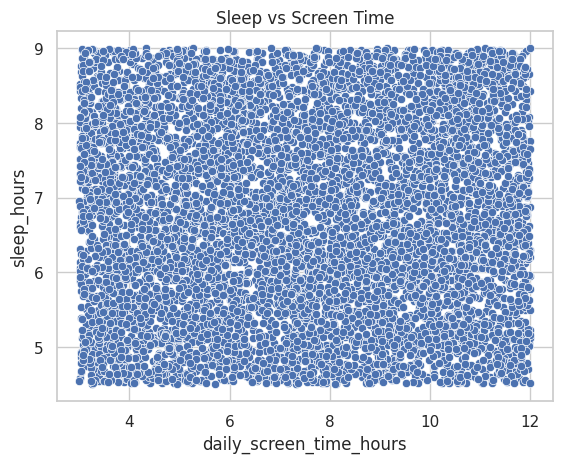

In [14]:
plt.figure()
sns.scatterplot(x="daily_screen_time_hours", y="sleep_hours", data=df)
plt.title("Sleep vs Screen Time")
plt.show()

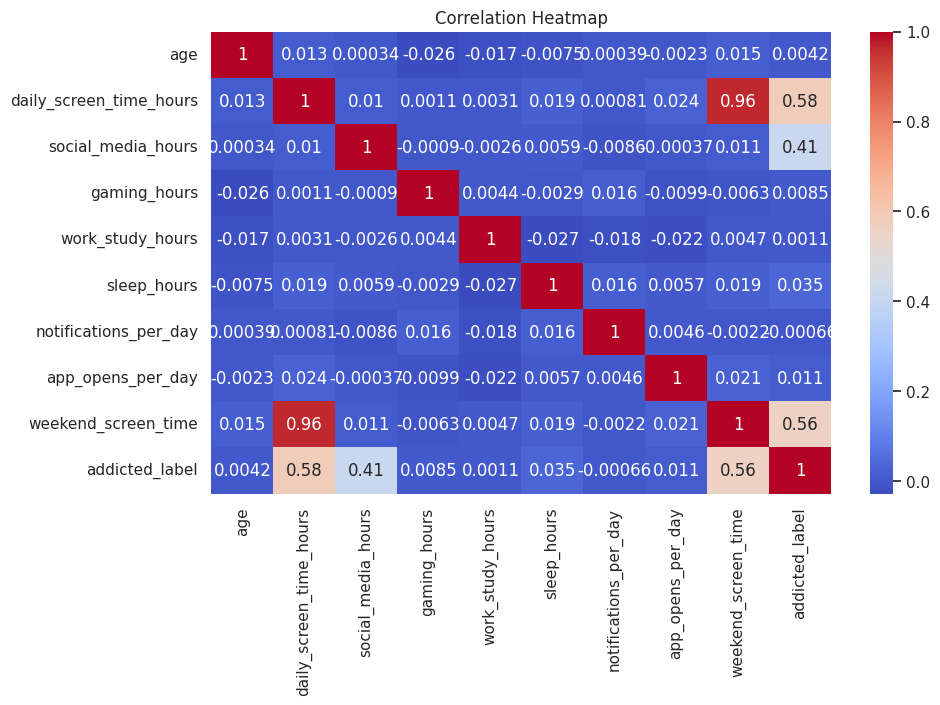

In [15]:
plt.figure(figsize=(10,6))
numeric_df=df.select_dtypes(include=["float64", "int64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
group=df.groupby("addicted_label").mean(numeric_only=True)
print(group)

                      age  daily_screen_time_hours  social_media_hours  \
addicted_label                                                           
0               26.534672                 5.156861            2.251615   
1               26.582894                 8.467502            3.695477   

                gaming_hours  work_study_hours  sleep_hours  \
addicted_label                                                
0                   1.999051          3.239672     6.666665   
1                   2.020431          3.243555     6.766839   

                notifications_per_day  app_opens_per_day  weekend_screen_time  
addicted_label                                                                 
0                          134.325730          97.000456             6.894535  
1                          134.229088          98.175961            10.213994  


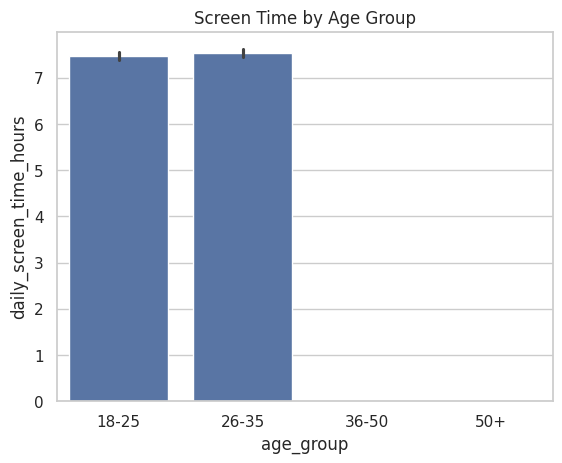

In [17]:
df["age_group"] = pd.cut(df["age"], bins=[0,25,35,50,100], labels=["18-25","26-35","36-50","50+"])
plt.figure()
sns.barplot(x="age_group", y="daily_screen_time_hours", data=df)
plt.title("Screen Time by Age Group")
plt.show()

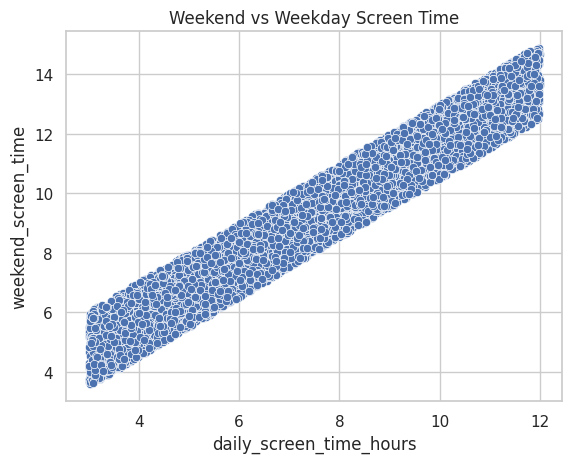

In [18]:
plt.figure()
sns.scatterplot(x="daily_screen_time_hours", y="weekend_screen_time", data=df)
plt.title("Weekend vs Weekday Screen Time")
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

NameError: name 'X' is not defined

In [ ]:
X = df.drop(["transaction_id", "user_id", "addicted_label", "age_group"], axis=1)
y = df["addicted_label"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
importances=pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()